In [1]:
from TKA_SHA_Mo_240503_2_copy import K0, dfg, calc_eq_methanation, phi_Soave
import numpy as np
from scipy.constants import R

In [2]:
T = np.linspace(400, 900, 50) + 273.15 # K

dfG_vals = np.zeros((len(T), 7))
dRGs_RWGS = np.zeros(len(T))
dRGS_CO_methanation = np.zeros(len(T))
dRGS_CO2_methanation = np.zeros(len(T))

for i, t in enumerate(T):
    dfG_vals[i, :] = dfg(t)
    dRGs_RWGS[i] = dfG_vals[i, 3] + dfG_vals[i, 4] - dfG_vals[i, 0] - 2 * dfG_vals[i, 1]
    dRGS_CO_methanation[i] = dfG_vals[i, 2] + dfG_vals[i, 3] - 3 * dfG_vals[i, 1] - dfG_vals[i, 4]
    dRGS_CO2_methanation[i] = dfG_vals[i, 2] + 2 * dfG_vals[i, 3] - 4 * dfG_vals[i, 1] - dfG_vals[i, 0]

In [3]:
# calculate drG from K0 values

K0_vals = np.zeros((len(T), 3))
DRG_vals_RWGS = np.zeros(len(T))
DRG_vals_CO_methanation = np.zeros(len(T))
DRG_vals_CO2_methanation = np.zeros(len(T))

for i, t in enumerate(T):
    K0_vals[i, 0] = K0(t, 'WGS') ** (-1)
    K0_vals[i, 1] = K0(t, 'CO methanation')
    K0_vals[i, 2] = K0(t, 'CO2 methanation')
    DRG_vals_RWGS[i] = - R * t * np.log(K0_vals[i, 0])
    DRG_vals_CO_methanation[i] = - R * t * np.log(K0_vals[i, 1])
    DRG_vals_CO2_methanation[i] = - R * t * np.log(K0_vals[i, 2])

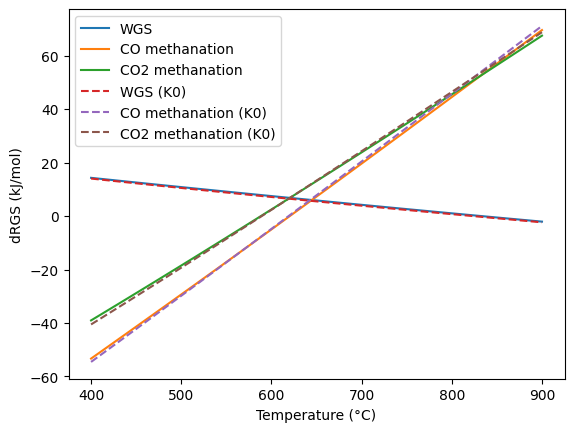

In [4]:
# plot dRGS vs T in kJ/mol
import matplotlib.pyplot as plt
plt.plot(T - 273.15, dRGs_RWGS / 1e3, label='WGS')
plt.plot(T - 273.15, dRGS_CO_methanation / 1e3, label='CO methanation')
plt.plot(T - 273.15, dRGS_CO2_methanation / 1e3, label='CO2 methanation')
plt.plot(T - 273.15, DRG_vals_RWGS / 1e3, '--', label='WGS (K0)')
plt.plot(T - 273.15, DRG_vals_CO_methanation / 1e3, '--', label='CO methanation (K0)')
plt.plot(T - 273.15, DRG_vals_CO2_methanation / 1e3, '--', label='CO2 methanation (K0)')
plt.xlabel('Temperature (°C)')
plt.ylabel('dRGS (kJ/mol)')
plt.legend()
plt.show()

# calculate relative error between dRGS and DRG
error_RWGS = np.abs(dRGs_RWGS - DRG_vals_RWGS) / np.abs(DRG_vals_RWGS)
error_CO_methanation = np.abs(dRGS_CO_methanation - DRG_vals_CO_methanation) / np.abs(DRG_vals_CO_methanation)
error_CO2_methanation = np.abs(dRGS_CO2_methanation - DRG_vals_CO2_methanation) / np.abs(DRG_vals_CO2_methanation)

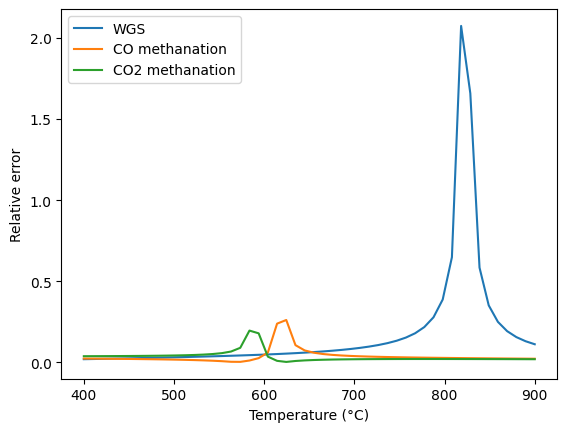

In [5]:
# plot relative error
plt.plot(T - 273.15, error_RWGS, label='WGS')
plt.plot(T - 273.15, error_CO_methanation, label='CO methanation')
plt.plot(T - 273.15, error_CO2_methanation, label='CO2 methanation')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative error')
plt.legend()
plt.show()

In [6]:
 #CO2, H2, CH4, H2O, CO, C and N2

In [7]:
T = np.linspace(200, 900, 50) + 273.15 # K

K0_WGS_dfG = np.zeros(len(T))
K0_CO_meth_dfG = np.zeros(len(T))
K0_CO2_meth_dfG = np.zeros(len(T))


for i, t in enumerate(T):
    dfG_vals = dfg(t)
    dRGs_WGS = - dfG_vals[3] - dfG_vals[4] + dfG_vals[0] + dfG_vals[1]
    K0_WGS_dfG[i] = np.exp(-dRGs_WGS / (R * t))
    dRGS_CO_meth = dfG_vals[2] + dfG_vals[3] - 3 * dfG_vals[1] - dfG_vals[4]
    K0_CO_meth_dfG[i] = np.exp(-dRGS_CO_meth / (R * t))
    dRGS_CO2_meth = dfG_vals[2] + 2 * dfG_vals[3] - 4 * dfG_vals[1] - dfG_vals[0]
    K0_CO2_meth_dfG[i] = np.exp(-dRGS_CO2_meth / (R * t))



In [8]:
# now calculate the equilbrium composition of the WGS reaction

#T = np.linspace(100, 900, 50) + 273.15 # K
p = 1e5 # Pa

x_0 = np.array([0.2, 0.8-5e-10, 1e-10, 1e-10, 1e-10, 1e-10, 1e-10]) # 1
x_eq = np.zeros((len(T), 7))
fug_coeffs = np.zeros((len(T), 6))

for i, t in enumerate(T):

    p, T_s, x0, x_GG, succ = calc_eq_methanation(t, p, x_0)
    x_eq[i, :] = x_GG
    # check if any x_eq_val is 1e-20
    if np.any(x_eq[i, :] <= 1e-20):
        print('Warning: x_eq has values < 1e-20')
    print(f'For T = {t-273.15:.2f}°C, the equilibrium composition is:')

    fug_coeffs[i, :] = phi_Soave(np.delete(x_eq[i, :], 5), t, p)

For T = 200.00°C, the equilibrium composition is:
For T = 214.29°C, the equilibrium composition is:
For T = 228.57°C, the equilibrium composition is:
For T = 242.86°C, the equilibrium composition is:
For T = 257.14°C, the equilibrium composition is:
For T = 271.43°C, the equilibrium composition is:
For T = 285.71°C, the equilibrium composition is:
For T = 300.00°C, the equilibrium composition is:
For T = 314.29°C, the equilibrium composition is:
For T = 328.57°C, the equilibrium composition is:
For T = 342.86°C, the equilibrium composition is:
For T = 357.14°C, the equilibrium composition is:
For T = 371.43°C, the equilibrium composition is:
For T = 385.71°C, the equilibrium composition is:
For T = 400.00°C, the equilibrium composition is:
For T = 414.29°C, the equilibrium composition is:
For T = 428.57°C, the equilibrium composition is:
For T = 442.86°C, the equilibrium composition is:
For T = 457.14°C, the equilibrium composition is:
For T = 471.43°C, the equilibrium composition is:


# K0 WGS

In [9]:
K0_WGS_Gmin = np.zeros(len(T))
K0_CO_meth_Gmin = np.zeros(len(T))
K0_CO2_meth_Gmin = np.zeros(len(T))

for i, t in enumerate(T):

    # check if any value in x_eq is smaller than 1e-20
    if np.any(x_eq[i, :-1] <= 5e-20):
        #print('Warning: x_eq has values < 1e-20')
        K0_WGS_Gmin[i] = np.nan
        K0_CO_meth_Gmin[i] = np.nan
        K0_CO2_meth_Gmin[i] = np.nan
        #print(i, x_eq[i, :])

    else:

        print('yay', t)
         #CO2, H2, CH4, H2O, CO, C and N2
    
        K0_WGS_Gmin[i] = x_eq[i, 0] * x_eq[i, 1] / (x_eq[i, 3] * x_eq[i, 4]) * fug_coeffs[i, 0] * fug_coeffs[i, 1] / (fug_coeffs[i, 3] * fug_coeffs[i, 4])
        K0_CO_meth_Gmin[i] = x_eq[i, 2] * x_eq[i, 3] / (x_eq[i, 1] ** 3 * x_eq[i, 4]) * fug_coeffs[i, 2] * fug_coeffs[i, 3] / (fug_coeffs[i, 1] ** 3 * fug_coeffs[i, 4])
        K0_CO2_meth_Gmin[i] = x_eq[i, 2] * x_eq[i, 3] ** 2 / (x_eq[i, 1] ** 4 * x_eq[i, 0]) * fug_coeffs[i, 2] * fug_coeffs[i, 3] ** 2 / (fug_coeffs[i, 1] ** 4 * fug_coeffs[i, 0])

yay 473.15
yay 487.43571428571425
yay 501.72142857142853
yay 516.0071428571429
yay 530.2928571428572
yay 544.5785714285714
yay 558.8642857142856
yay 573.15
yay 587.4357142857143
yay 601.7214285714285
yay 616.0071428571429
yay 630.2928571428571
yay 644.5785714285714
yay 658.8642857142856
yay 673.15
yay 687.4357142857143
yay 701.7214285714285
yay 716.0071428571429
yay 730.2928571428572
yay 744.5785714285714
yay 758.8642857142856
yay 773.15
yay 787.4357142857142
yay 801.7214285714286
yay 816.0071428571429
yay 830.2928571428571
yay 844.5785714285714
yay 858.8642857142858
yay 873.15
yay 887.4357142857143
yay 901.7214285714286
yay 916.0071428571429
yay 930.2928571428571
yay 944.5785714285714
yay 958.8642857142858
yay 973.15
yay 987.4357142857143
yay 1001.7214285714285
yay 1016.0071428571429
yay 1030.2928571428572
yay 1044.5785714285714
yay 1058.8642857142859
yay 1073.15
yay 1087.4357142857143
yay 1101.7214285714285
yay 1116.0071428571428
yay 1130.2928571428572
yay 1144.5785714285714
yay 1158

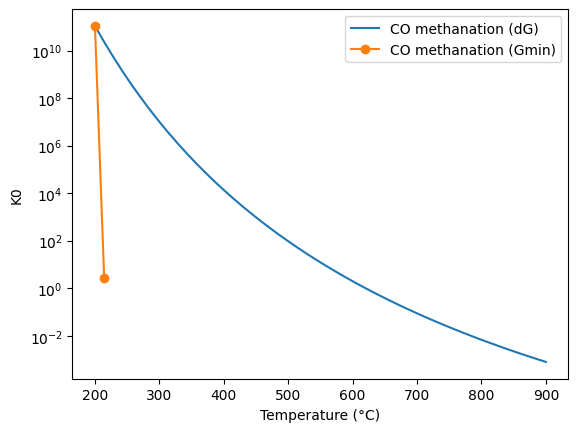

In [10]:
# plot both K0 values

#plt.plot(T - 273.15, K0_WGS_dfG, label='WGS (dG)')
#plt.plot(T - 273.15, K0_WGS_Gmin, label='WGS (Gmin)', marker='o')
plt.plot(T - 273.15, K0_CO_meth_dfG, label='CO methanation (dG)')
plt.plot(T - 273.15, K0_CO_meth_Gmin, label='CO methanation (Gmin)', marker='o')
#plt.plot(T - 273.15, K0_CO2_meth_dfG, label='CO2 methanation (dG)')
#plt.plot(T - 273.15, K0_CO2_meth_Gmin, label='CO2 methanation (Gmin)', marker='o')
plt.xlabel('Temperature (°C)')
plt.ylabel('K0')
#plt.ylim(-100, 1e5)
plt.yscale('log')
plt.legend()
plt.show()

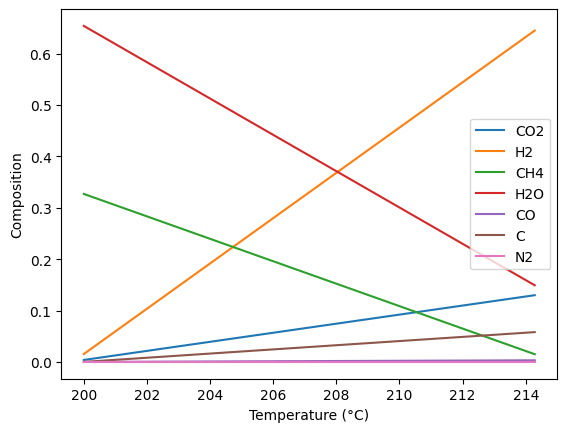

In [11]:
# plot equilibrium composition
plt.plot(T - 273.15, x_eq[:, 0], label='CO2')
plt.plot(T - 273.15, x_eq[:, 1], label='H2')
plt.plot(T - 273.15, x_eq[:, 2], label='CH4')
plt.plot(T - 273.15, x_eq[:, 3], label='H2O')
plt.plot(T - 273.15, x_eq[:, 4], label='CO')
plt.plot(T - 273.15, x_eq[:, 5], label='C')
plt.plot(T - 273.15, x_eq[:, 6], label='N2')
plt.xlabel('Temperature (°C)')
plt.ylabel('Composition')
plt.legend()
plt.show()